# GP Exact Regression Tutorial

Purpose: model a beam-deflection surrogate with calibrated uncertainty.

- Train range: `[-4, 4]`
- Test range: `[-6, 6]` (includes OOD)
- Metrics: RMSE, Gaussian NLL, 95% coverage, interval width


## Learning Roadmap

- Build intuition for interpolation vs extrapolation with exact GP.
- Inspect residuals and uncertainty trends, not just the mean fit.
- Use calibration metrics (NLL/coverage) to evaluate confidence quality.


In [1]:
# Step 1: import local package and plotting dependencies
# Configure Python path for local package imports
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'gp' else Path.cwd().resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)

from deepuq.models import GaussianProcessRegressor, RBFKernel


In [2]:
# Step 2: define reusable regression calibration metrics
def regression_metrics(y_true, mean, var):
    y_true = y_true.reshape(-1)
    mean = mean.reshape(-1)
    var = var.reshape(-1).clamp_min(1e-8)
    rmse = torch.sqrt(torch.mean((mean - y_true) ** 2)).item()
    nll = 0.5 * torch.mean(torch.log(2 * torch.pi * var) + (y_true - mean) ** 2 / var).item()
    std = torch.sqrt(var)
    lower = mean - 1.96 * std
    upper = mean + 1.96 * std
    coverage95 = torch.mean(((y_true >= lower) & (y_true <= upper)).float()).item()
    width95 = torch.mean(upper - lower).item()
    return {
        'rmse': rmse,
        'nll': nll,
        'coverage95': coverage95,
        'interval_width95': width95,
    }


In [3]:
# Step 3: create synthetic beam-style dataset with in-domain and OOD ranges
# Engineering-inspired deflection function
x_train = torch.linspace(-4, 4, 80).unsqueeze(-1)
true_fn = lambda x: 0.25 * x + torch.sin(1.3 * x) - 0.08 * x**2
y_train = true_fn(x_train) + 0.12 * torch.randn_like(x_train)

x_test = torch.linspace(-6, 6, 300).unsqueeze(-1)
y_test = true_fn(x_test)


In [4]:
# Step 4: fit exact GP and compute predictive uncertainty
kernel = RBFKernel(lengthscale=0.8, outputscale=1.5, jitter=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, noise=0.014)

start = time.perf_counter()
gp.fit(x_train, y_train)
fit_time = time.perf_counter() - start

with torch.no_grad():
    uq = gp.predict_uq(x_test)
metrics = regression_metrics(y_test.squeeze(-1), uq.mean, uq.total_var)
print({'fit_time_sec': round(fit_time, 4), **{k: round(v, 4) for k, v in metrics.items()}})


{'fit_time_sec': 0.0009, 'rmse': 1.3721, 'nll': 0.5047, 'coverage95': 0.8333, 'interval_width95': 1.4059}


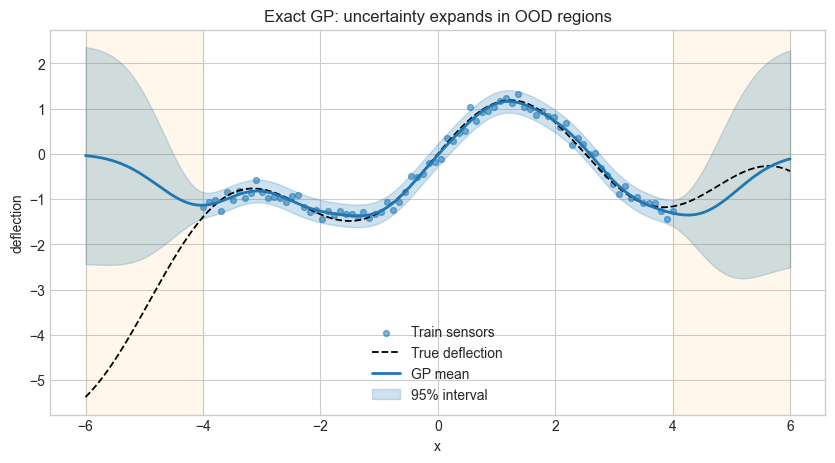

In [5]:
# Step 5: visualize posterior mean and 95% confidence interval
std = torch.sqrt(uq.total_var)
plt.figure(figsize=(10, 5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=18, alpha=0.55, label='Train sensors')
plt.plot(x_test.numpy(), y_test.numpy(), 'k--', lw=1.3, label='True deflection')
plt.plot(x_test.numpy(), uq.mean.numpy(), color='tab:blue', lw=2.0, label='GP mean')
plt.fill_between(
    x_test.squeeze(-1).numpy(),
    (uq.mean - 1.96 * std).numpy(),
    (uq.mean + 1.96 * std).numpy(),
    alpha=0.22,
    color='tab:blue',
    label='95% interval',
)
plt.axvspan(-6, -4, color='orange', alpha=0.08)
plt.axvspan(4, 6, color='orange', alpha=0.08)
plt.title('Exact GP: uncertainty expands in OOD regions')
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('deflection')
plt.show()


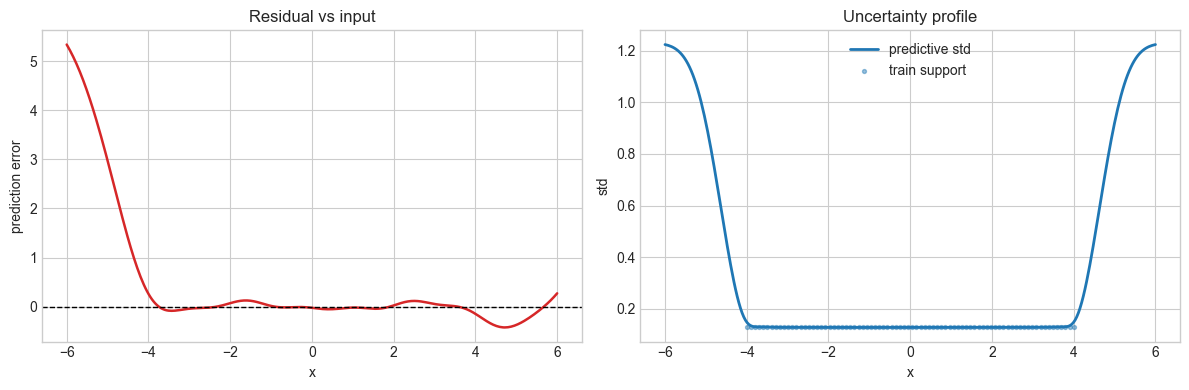

In [6]:
# Additional diagnostic: residual and predictive uncertainty profile
# This plot helps us verify where the model is biased and where confidence increases.
residual = uq.mean - y_test.squeeze(-1)
pred_std = torch.sqrt(uq.total_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_test.numpy(), residual.numpy(), color='tab:red', lw=1.8)
axes[0].axhline(0.0, color='k', ls='--', lw=1)
axes[0].set_title('Residual vs input')
axes[0].set_xlabel('x')
axes[0].set_ylabel('prediction error')

axes[1].plot(x_test.numpy(), pred_std.numpy(), color='tab:blue', lw=2, label='predictive std')
axes[1].scatter(x_train.numpy(), torch.full_like(x_train, pred_std.min().item()), s=8, alpha=0.45, label='train support')
axes[1].set_title('Uncertainty profile')
axes[1].set_xlabel('x')
axes[1].set_ylabel('std')
axes[1].legend(loc='best')
plt.tight_layout()
plt.show()
